# Esercizio 3.3 - Valutazione ed Inferenza Faster R-CNN

Questo notebook e' dedicato alla valutazione quantitativa e qualitativa del modello **Faster R-CNN** addestrato sul dataset GTSRB.

Obiettivi principali:
1. **Valutazione quantitativa**: calcolo del **Mean Average Precision (mAP)** complessivo e alle soglie IoU 0,50 e 0,75 tramite `torchmetrics`.
2. **Valutazione qualitativa**: confronto tra bounding box reali e predette, filtrate tramite una soglia di confidenza.

In [6]:
import sys
if '..' not in sys.path:
    sys.path.append('..')

import torch
from torchmetrics.detection.mean_ap import MeanAveragePrecision
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from omegaconf import OmegaConf

from src.detection_data import LitGTSRBDetectionDataModule
from src.lightning_modules import LitFasterRCNN
from src.utils import find_best_metric_checkpoint

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device selezionato: {device}")

Device selezionato: cuda


In [7]:
# Caricamento della configurazione
cfg = OmegaConf.load('config_detection.yaml')

# Inizializzazione del DataModule
dm = LitGTSRBDetectionDataModule(
    cache_dir=cfg.dataset.data_dir,
    batch_size=cfg.dataset.batch_size,
    num_workers=cfg.dataset.num_workers
)
dm.setup()
val_loader = dm.val_dataloader()

In [8]:
# Carichiamo esclusivamente il miglior detector addestrato con backbone GTSRB.
checkpoint_path = find_best_metric_checkpoint(
    checkpoint_dir=cfg.evaluation.checkpoint_dir,
    filename_prefix=cfg.evaluation.checkpoint_prefix,
    metric_name=cfg.evaluation.checkpoint_metric,
)
print(f"Caricamento modello dal checkpoint: {checkpoint_path}")
model = LitFasterRCNN.load_from_checkpoint(
    checkpoint_path,
    backbone_image_mean=list(cfg.model.backbone_image_mean),
    backbone_image_std=list(cfg.model.backbone_image_std),
)
model.to(device)
model.eval()  # Imposta il modello in modalita' inferenza.
print("Modello caricato e pronto per l'inferenza.")

Caricamento modello dal checkpoint: checkpoints\faster_rcnn_gtsrb_fpn\faster_rcnn_resnet50_gtsrb-epoch=09-val_mAP_50=0.207.ckpt
Modello caricato e pronto per l'inferenza.


In [4]:
# Calcolo del Mean Average Precision (mAP) sul validation set.
print("Calcolo del mAP in corso sul validation set...")
metric = MeanAveragePrecision(backend="faster_coco_eval")
with torch.no_grad():
    for images, targets in val_loader:
        # Spostiamo le immagini sul device
        images_device = [img.to(device) for img in images]
        
        # Eseguiamo l'inferenza
        preds = model(images_device)
        
        # Riportiamo le predizioni e i target su CPU per calcolare la metrica
        preds_cpu = [{k: v.cpu() for k, v in p.items()} for p in preds]
        targets_cpu = [{k: v.cpu() for k, v in t.items()} for t in targets]
        
        metric.update(preds_cpu, targets_cpu)

results = metric.compute()
print("\n--- Risultati Metric Validation ---")
print(f"mAP (IoU=0.50:0.95): {results['map'].item():.4f}")
print(f"mAP_50 (IoU=0.50):    {results['map_50'].item():.4f}")
print(f"mAP_75 (IoU=0.75):    {results['map_75'].item():.4f}")

Calcolo del mAP in corso sul validation set...

--- Risultati Metric Validation ---
mAP (IoU=0.50:0.95): 0.1374
mAP_50 (IoU=0.50):    0.2105
mAP_75 (IoU=0.75):    0.1499


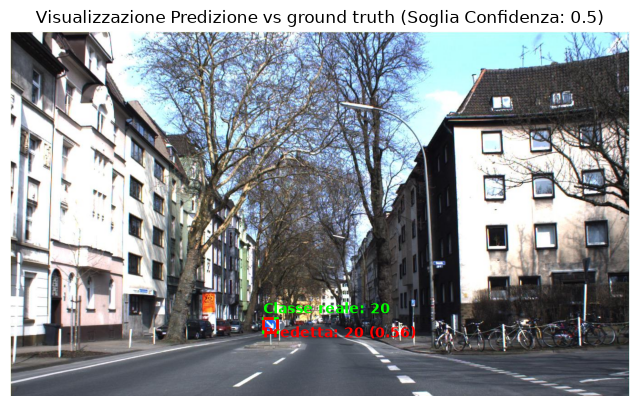

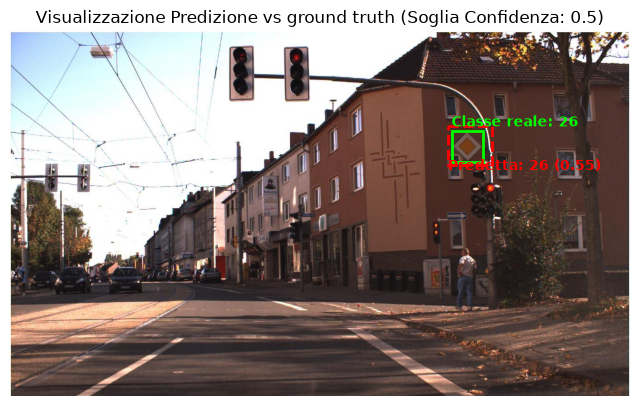

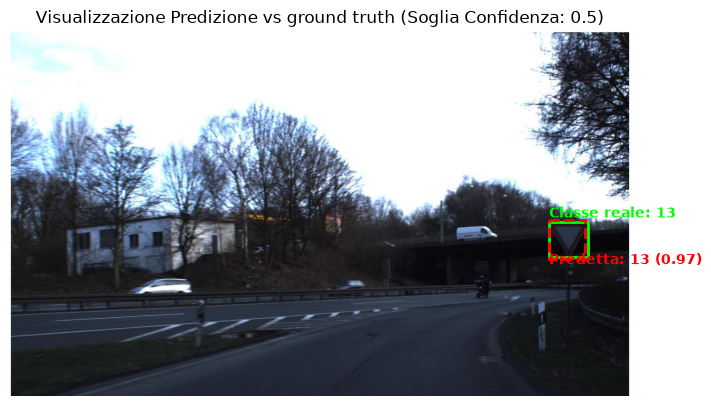

In [5]:
# Funzione per la visualizzazione delle predizioni e del ground truth
def plot_predictions(img_tensor, target, prediction, score_threshold=0.5):
    """Visualizza ground truth e detection che superano la soglia indicata."""
    img_np = img_tensor.permute(1, 2, 0).cpu().numpy()
    
    fig, ax = plt.subplots(1, figsize=(8, 8))
    ax.imshow(img_np)
    
    # Disegna il ground truth in verde.
    gt_boxes = target['boxes'].cpu().numpy()
    gt_labels = target['labels'].cpu().numpy()
    for box, label in zip(gt_boxes, gt_labels):
        xmin, ymin, xmax, ymax = box
        width = xmax - xmin
        height = ymax - ymin
        rect = patches.Rectangle(
            (xmin, ymin), width, height,
            linewidth=2, edgecolor='lime', facecolor='none'
        )
        ax.add_patch(rect)
        ax.text(xmin, ymin - 10, f'Classe reale: {label}', color='lime', fontsize=10, weight='bold')
        
    # Disegna le predizioni in rosso filtrandole per soglia di confidenza.
    pred_boxes = prediction['boxes'].cpu().numpy()
    pred_labels = prediction['labels'].cpu().numpy()
    pred_scores = prediction['scores'].cpu().numpy()
    
    for box, label, score in zip(pred_boxes, pred_labels, pred_scores):
        if score < score_threshold:
            continue
        xmin, ymin, xmax, ymax = box
        width = xmax - xmin
        height = ymax - ymin
        rect = patches.Rectangle(
            (xmin, ymin), width, height,
            linewidth=2, edgecolor='red', facecolor='none', linestyle='--'
        )
        ax.add_patch(rect)
        ax.text(xmin, ymax + 12, f'Predetta: {label} ({score:.2f})', color='red', fontsize=10, weight='bold')
        
    plt.axis('off')
    plt.title("Visualizzazione Predizione vs ground truth (Soglia Confidenza: " + str(score_threshold) + ")")
    plt.show()

# Cerchiamo tre esempi che contengano almeno una detection sopra soglia.
score_threshold = 0.5
selected_examples = []
fallback_examples = []

with torch.no_grad():
    for images, targets in val_loader:
        predictions = model([image.to(device) for image in images])
        for image, target, prediction in zip(images, targets, predictions):
            example = (image, target, prediction)
            if len(fallback_examples) < 3:
                fallback_examples.append(example)
            if (prediction['scores'] >= score_threshold).any():
                selected_examples.append(example)
            if len(selected_examples) == 3:
                break
        if len(selected_examples) == 3:
            break

# Il fallback mantiene la cella utilizzabile anche con un modello molto debole.
examples_to_plot = selected_examples or fallback_examples
for image, target, prediction in examples_to_plot:
    plot_predictions(image, target, prediction, score_threshold=score_threshold)

**Osservazioni**

- Il checkpoint ricaricato ottiene `mAP = 0,1374`, `mAP_50 = 0,2105` e `mAP_75 = 0,1499`.
- I valori coincidono con la verifica indipendente eseguita al termine del notebook `04`, confermando che il salvataggio e il caricamento del modello sono corretti.
- La distanza tra mAP_50 e mAP_75 mostra che la localizzazione approssimativa e' piu' semplice di quella richiesta a una soglia IoU elevata.
- Il risultato e' coerente con la difficolta' del dataset: i segnali occupano spesso una porzione molto piccola dell'immagine e alcune classi sono poco rappresentate.
- Nei tre esempi selezionati automaticamente, la classe predetta coincide con quella reale e le bounding box risultano ben sovrapposte. Due detection hanno confidenza moderata (0,56 e 0,55), mentre la terza raggiunge 0,97.